# 4.0 Model training - LightGBM


## Imports


In [1]:
import numpy as np
import pandas as pd
import joblib
import json
import shap
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_log_error

from recruit_restaurant_visitor_forecasting.config import (
    AIR_RESTAURANT_ID_COL,
    MODELS_DIR,
    VISIT_DATE_COL,
    DAY_OF_WEEK_COL,
    VISITORS_NBR_COL,
    CITY_COL,
)
from recruit_restaurant_visitor_forecasting.dataset import read_csv, DataDir, save_csv
from recruit_restaurant_visitor_forecasting.modeling.train import (
    build_feature_drop_list,
    load_data,
    prepare_features,
    light_gbm_gridsearch,
    select_features_with_permutation_importance,
    train_test_split_by_date,
)
from recruit_restaurant_visitor_forecasting.plots import plot_daily_pred, plot_feature_importances
from recruit_restaurant_visitor_forecasting.utils import merge_daily_pred, convert_to_serializable, get_format
from recruit_restaurant_visitor_forecasting.modeling.predict import recursive_predict

2026-01-05 19:44:35.918 | INFO     | recruit_restaurant_visitor_forecasting.config:<module>:12 - PROJ_ROOT path is: D:\mentoring_program


In [2]:
CV_SPLITS = 3
TEST_SIZE = 0.2
DROP_COLUMNS = [AIR_RESTAURANT_ID_COL, VISIT_DATE_COL, VISITORS_NBR_COL, DAY_OF_WEEK_COL, CITY_COL]

PERM_TOP_K = 35
PERM_N_REPEATS = 5
PERM_VALID_SIZE = 0.2

MODEL_PATH = MODELS_DIR / "lightgbm_model.pkl"

## Load and prepare

In [3]:
features, labels = load_data()
print(f"Features shape: {features.shape}")
print(f"Labels shape: {labels.shape}")

Features shape: (271221, 50)
Labels shape: (271221,)


In [4]:
original_index = features.index.copy()
features = prepare_features(features)

labels = labels.loc[features.index].reset_index(drop=True)
features = features.reset_index(drop=True)

In [5]:
X = features
y = labels

In [6]:
X_train, X_test, y_train, y_test = train_test_split_by_date(
    X, y, date_col=VISIT_DATE_COL, test_size=TEST_SIZE
)

train_dates = X_train[VISIT_DATE_COL]
test_dates = X_test[VISIT_DATE_COL]

print(f"Train set dates: {train_dates.min()} to {train_dates.max()}")
print(f"Test set dates: {test_dates.min()} to {test_dates.max()}")

Train set dates: 2016-02-01 00:00:00 to 2017-01-22 00:00:00
Test set dates: 2017-01-23 00:00:00 to 2017-04-22 00:00:00


## Feature selection

In [7]:
selected_features, perm_importances = select_features_with_permutation_importance(
    X_train,
    y_train,
    drop_features=DROP_COLUMNS,
    test_size=PERM_VALID_SIZE,
    n_repeats=PERM_N_REPEATS,
    top_k=PERM_TOP_K,
)

FEATURES_TO_DROP = build_feature_drop_list(
    X.columns.tolist(),
    selected_features,
)
FEATURES_TO_KEEP = [c for c in X.columns if c not in FEATURES_TO_DROP]

print("Selected features: ", selected_features)
perm_importances.head()

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.015893 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 8931
[LightGBM] [Info] Number of data points in the train set: 138296, number of used features: 45
[LightGBM] [Info] Start training from score 17.665797
Selected features:  ['visitors_dow_mean', 'total_reserves', 'res_visitors_diff_mean_14', 'visitors_mean_7', 'res_visitors_diff_mean_7', 'open_usually', 'res_visitors_diff', 'visitors_lag_7', 'visitors_lag_28', 'holiday_flg', 'visitors_nbrs_lag_1', 'visitors_lag_1', 'visitors_median_7', 'visitors_mean_28', 'res_visitors_diff_mean_28', 'visitors_std_7', 'total_reserves_nbrs', 'days_from_holiday', 'visitors_median_14', 'visitors_mean_14', 'visitors_median_28', 'days_from_last_visit', 'visitors_std_14', 'nbr_res_visitors_diff', 'visitors_std_28', 'visitors_dow_mean_nbrs', 'air_city_te', 'air_genre_te', 'visitors_nbrs_mean_28', 'opened_recently', 'visit

,feature,importance_mean,importance_std
0,visitors_dow_mean,0.196650,0.001270
1,total_reserves,0.076606,0.001710
2,res_visitors_diff_mean_14,0.057876,0.000966
3,visitors_mean_7,0.055085,0.001116
4,res_visitors_diff_mean_7,0.048972,0.000855


## Training


In [9]:
grid_search = light_gbm_gridsearch(
    verbose=3,
    n_jobs=-1,
    drop_features=FEATURES_TO_DROP,
    n_splits=CV_SPLITS,
)
grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best score:", grid_search.best_score_)

Fitting 3 folds for each of 1458 candidates, totalling 4374 fits
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.017857 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 6785
[LightGBM] [Info] Number of data points in the train set: 197104, number of used features: 35
[LightGBM] [Info] Start training from score 17.605584
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best ga

In [10]:
pd.DataFrame(grid_search.cv_results_).sort_values("rank_test_score").head()

,mean_fit_time,std_fit_time,mean_score_time,std_score_time,param_model__learning_rate,param_model__max_depth,param_model__min_child_samples,param_model__n_estimators,param_model__num_leaves,param_model__reg_alpha,param_model__reg_lambda,params,split0_test_score,split1_test_score,split2_test_score,mean_test_score,std_test_score,rank_test_score
377,8.956943,0.666931,0.010011,0.004290,0.1,5,10,200,31,1.0,1.0,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.617611,-0.613862,-0.786972,-0.672815,0.080736,1
478,6.615666,0.604260,0.006496,0.000125,0.1,5,30,200,31,0.0,0.1,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.617409,-0.613880,-0.788256,-0.673181,0.081383,2
481,7.091238,0.520005,0.006724,0.000532,0.1,5,30,200,31,0.1,0.1,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.615850,-0.610308,-0.795081,-0.673746,0.085826,3
483,7.542804,0.156827,0.007319,0.000625,0.1,5,30,200,31,1.0,0.0,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.620729,-0.614656,-0.785967,-0.673784,0.079364,4
423,6.719848,0.041816,0.006235,0.000727,0.1,5,20,200,31,0.0,0.0,"{'model__learning_rate': 0.1, 'model__max_dept...",-0.623034,-0.606745,-0.792370,-0.674050,0.083929,5


In [11]:
model = grid_search.best_estimator_
y_train_pred = model.predict(X_train)
y_train_pred = np.maximum(y_train_pred, 0)

train_rmsle = np.sqrt(mean_squared_log_error(y_train, y_train_pred))
train_mae = mean_absolute_error(y_train, y_train_pred)
train_r2 = r2_score(y_train, y_train_pred)

print(f"Train set metrics:")
print(f"RMSLE: {train_rmsle:.4f}")
print(f"MAE:  {train_mae:.4f}")
print(f"R2:   {train_r2:.4f}")

Train set metrics:
RMSLE: 0.8306
MAE:  6.5346
R2:   0.6534


In [13]:
y_test_pred, temp_features = recursive_predict(
    model,
    X_test,
    X_train,
    y_train,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively:   0%|          | 0/90 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.91006092e+01 1.27461907e+01 8.26665591e+00 5.83516203e+00
 4.44434388e+00 1.98943352e+01 1.18437960e+01 3.85898355e+01
 3.12027849e+01 7.69416292e+00 2.90354034e+01 3.56169919e+00
 1.85636267e+01 2.99270942e+01 1.42337988e+01 8.91220579e+00
 8.46125915e-01 7.09344823e+00 2.77014638e+00 2.79993200e+01
 2.19033329e+01 3.51185701e+01 5.94042247e+00 1.11049392e+01
 9.71271057e+00 1.54844865e+01 4.58513499e+00 9.61963801e+00
 7.94465943e+00 2.55157579e+01 0.00000000e+00 4.23180879e+01
 2.60002012e+01 5.80901778e+00 5.07151608e-01 2.62320301e+01
 9.06624753e+00 3.49753103e+00 1.13054317e+01 9.44218636e+00
 1.59253393e+00 7.70040411e+00 1.35276460e+01 5.10113851e+00
 1.97847525e-01 1.79018414e+01 9.27402726e+00 4.19969

In [14]:
test_rmsle = np.sqrt(mean_squared_log_error(y_test, y_test_pred))
test_mae = mean_absolute_error(y_test, y_test_pred)
test_r2 = r2_score(y_test, y_test_pred)
print(f"\nTest set metrics:")
print(f"RMSLE: {test_rmsle:.4f}")
print(f"MAE:  {test_mae:.4f}")
print(f"R2:   {test_r2:.4f}")


Test set metrics:
RMSLE: 0.8454
MAE:  7.0717
R2:   0.5664


## Graphs

### Feature importances

<Figure size 1200x1000 with 0 Axes>

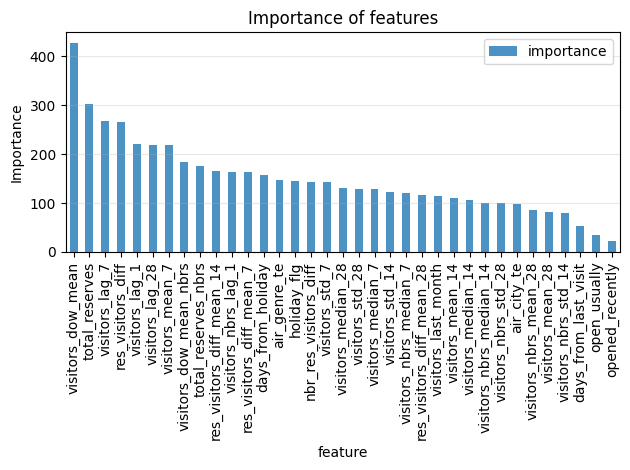

In [12]:
plot_feature_importances(model, FEATURES_TO_KEEP)

## SHAP explanation

In [15]:
X_test_clean = model.named_steps["feature_dropper"].transform(X_test)
lgbm = model.named_steps["model"]

explainer = shap.Explainer(lgbm)
shap_values = explainer(X_test_clean)

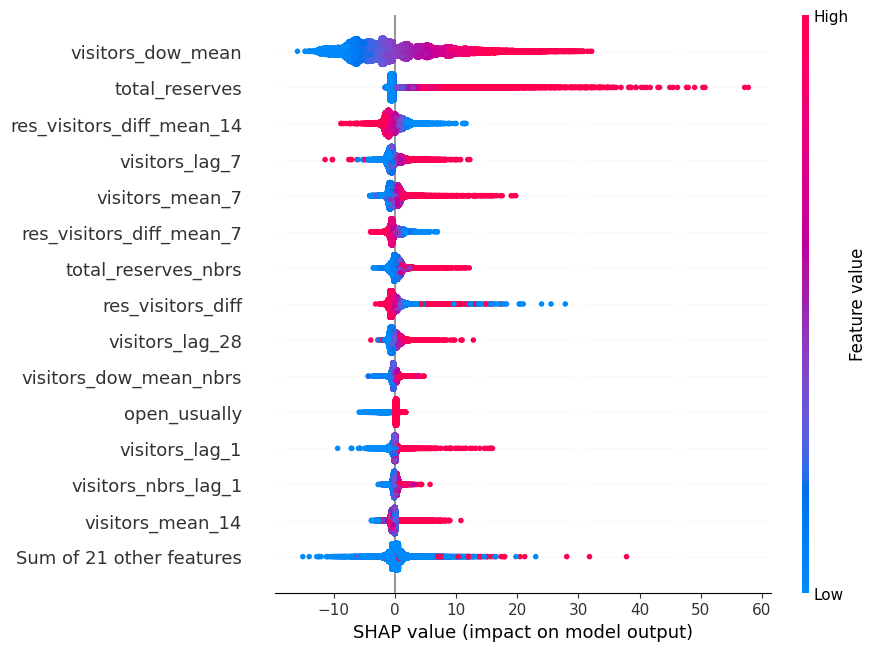

In [12]:
shap.plots.beeswarm(shap_values, max_display=15)

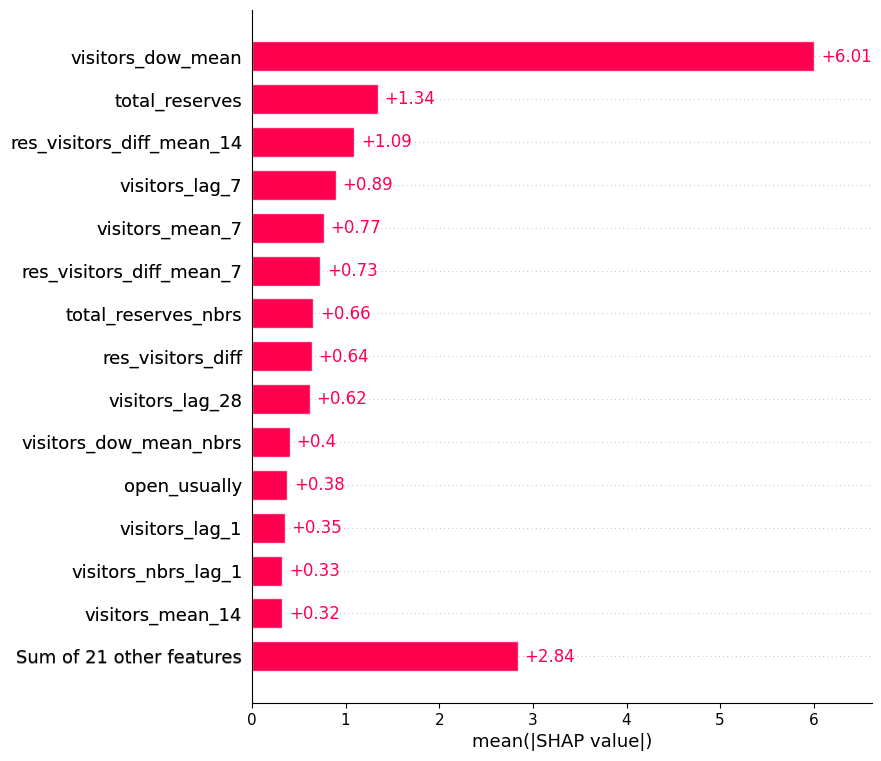

In [16]:
shap.plots.bar(shap_values, max_display=15)

### Visitors per day: actual vs predicted

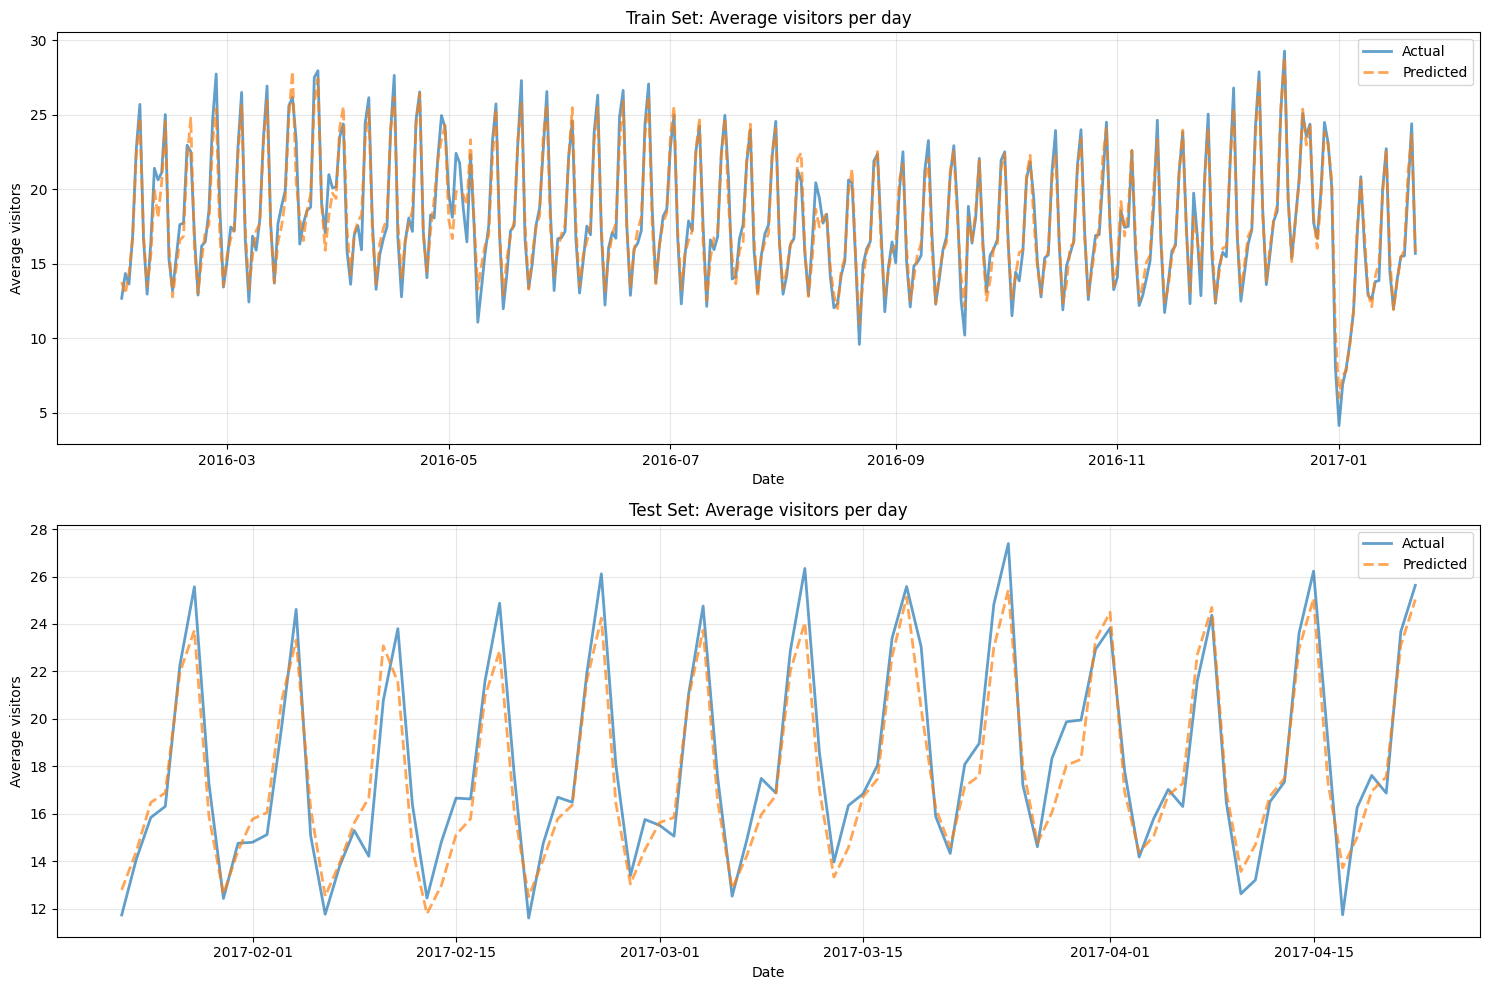

In [16]:
train_daily = merge_daily_pred(train_dates, y_train, y_train_pred)
test_daily = merge_daily_pred(test_dates, y_test, y_test_pred)

fig, axes = plt.subplots(2, 1, figsize=(15, 10))

plot_daily_pred(train_daily, axes[0], train=True)
plot_daily_pred(test_daily, axes[1], train=False)

plt.tight_layout()
plt.show()

## Testing on future data

In [7]:
model = joblib.load(MODEL_PATH)

In [17]:
test_features = read_csv("test_features.csv", DataDir.PROCESSED)
test_features = prepare_features(test_features)

In [ ]:
test_labels, temp_features = recursive_predict(
    model,
    test_features,
    X,
    y,
    drop_cols=FEATURES_TO_DROP,
)

Predicting recursively:   0%|          | 0/39 [00:00<?, ?it/s]D:\mentoring_program\recruit_restaurant_visitor_forecasting\modeling\predict.py:148: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[8.37109180e-01 3.37248204e-01 1.03479339e+01 4.61913489e+00
 2.57255563e+01 2.44264685e+01 2.66304582e+01 0.00000000e+00
 3.81849941e+01 1.75945609e+00 2.07324722e+01 4.66859705e+00
 2.73439303e+01 4.88731527e+01 2.38031978e+01 4.88283135e+00
 1.37481231e+01 1.15919158e+01 2.18970885e+01 5.16956968e+01
 5.73355060e+00 1.47841959e+01 1.43137226e+01 1.73611958e+01
 1.18424672e+00 3.00433979e+01 1.20250116e+01 2.23104833e+01
 7.80323992e-01 1.26528850e+01 2.12320051e+01 3.69215266e+00
 1.75362835e+01 9.64891485e+00 7.78135746e+00 0.00000000e+00
 1.27626680e+00 3.37576768e+01 2.05661007e+01 1.26103780e+01
 3.62562838e+01 3.65576604e+01 5.32703168e+00 7.86164364e-01
 1.58474846e+01 1.54115822e+01 1.91655124e+00 1.17306

In [19]:
labels_format = get_format(test_features, test_labels)
save_csv(labels_format, "test_labels.csv", DataDir.PROCESSED)

## Saving model

In [17]:
joblib.dump(model, MODEL_PATH)

params_to_save = {
    "best_params": convert_to_serializable(grid_search.best_params_),
    "best_score": float(grid_search.best_score_),
}

params_path = MODELS_DIR / "lightgbm_model_params.json"
with open(params_path, 'w', encoding='utf-8') as f:
    json.dump(params_to_save, f, indent=2, ensure_ascii=False)